# Directed Evolution loop — V1

First simple test of `sequence_classesV1.py` (`Protocol`, `Lambda`) and `analysisV1.py`
(the 8 plotting/analysis functions), on a small toy library.

Pipeline for one round of `Protocol.loop_DE()`:

$$
\lambda_0 \xrightarrow{\text{NGS}} \lambda_0' \qquad
\lambda_0 \xrightarrow{\text{sampling}} \lambda_1 \xrightarrow{\text{produce\_capsids}} \lambda_2 \xrightarrow{\text{NGS}} \lambda_2' \qquad
\lambda_2 \xrightarrow{\text{selectivty}} \lambda_3 \xrightarrow{\text{NGS}} \lambda_3' \qquad
\lambda_3 \xrightarrow{\text{bacterial\_amplification}} \lambda_4
$$

`lambda0/1/2/3/4` = true pools (biological chain). `lambda0p/2p/3p` = NGS read-count
snapshots (side channel, Negative Binomial, never fed back into the chain).


## 0. Protocol parameters

Fixed constants from `sequence_classesV1.py`, used as defaults throughout `Protocol` unless overridden at construction time.

In [1]:
import sequence_classesV1
print(sequence_classesV1.__file__)
print(sequence_classesV1.message)

/Users/merlincc/Library/Mobile Documents/com~apple~CloudDocs/IDV AAV/Directed-Evolution-loop/Modelization_V1/sequence_classesV1.py
file 1.9


In [2]:
import analysisV1
print(analysisV1.__file__)
print(analysisV1.message)

/Users/merlincc/Library/Mobile Documents/com~apple~CloudDocs/IDV AAV/Directed-Evolution-loop/Modelization_V1/analysisV1.py
file analysis 2.1


In [3]:
import pandas as pd
from sequence_classesV1 import rho, alpha, epsilon, T_sel, T_viab, M, K_MM, K_MM_amp, N_pcr, D, N1, phi

params = pd.DataFrame([
    ("rho",     rho,     "HEK cells transfected per plasmid"),
    ("alpha",   alpha,   "capsid yield per transfected cell"),
    ("epsilon", epsilon, "per-cell production noise amplitude"),
    ("T_sel",   T_sel,   "selectivity temperature"),
    ("T_viab",  T_viab,  "viability temperature (larger = more uniform production)"),
    ("M",       M,       "number of PCR amplification cycles"),
    ("K_MM",    K_MM,    "Michaelis-Menten saturation constant for PCR"),
    ("K_MM_amp",K_MM_amp,"same as before"),
    ("N_pcr",   N_pcr,   "pipetting depth before PCR amplification (NGS pipeline)"),
    ("D",       D,       "sequencing depth (reads per NGS readout)"),
    ("N1",      N1,      "number of plasmids sampled for transfection"),
    ("phi",     phi,     "NB dispersion for sequencing reads (smaller phi = closer to Poisson)"),
], columns=["Parameter", "Value", "Description"])

params

,Parameter,Value,Description
0,rho,1.000000e-03,HEK cells transfected per plasmid
1,alpha,4.000000e+03,capsid yield per transfected cell
2,epsilon,1.000000e-02,per-cell production noise amplitude
3,T_sel,5.000000e-01,selectivity temperature
4,T_viab,5.000000e-01,viability temperature (larger = more uniform p...
5,M,4.000000e+01,number of PCR amplification cycles
6,K_MM,1.000000e+06,Michaelis-Menten saturation constant for PCR
7,K_MM_amp,1.000000e+08,same as before
8,N_pcr,1.000000e+06,pipetting depth before PCR amplification (NGS ...
9,D,1.000000e+10,sequencing depth (reads per NGS readout)


## 1. Imports

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from sequence_classesV1 import *
from analysisV1 import *

## 2. Toy library and ground-truth (Teacher) Potts model

Small library so the whole notebook runs in seconds. `F_viab`/`F_sel` are dense
random profile matrices; `J_viab`/`J_sel` are *sparse* (only a handful of nonzero
pairwise couplings each) — a dense random `J` blows up `exp(score/T)` in
`produce_capsids` since it sums scores over every transfected cell.

In [5]:
key = jax.random.key(0)
key, k_seq, k_Fv, k_Fs, k_Jv, k_Js = jax.random.split(key, 6)

num_sequences   = 800000
L               = 7     # sequence length
A               = 20    # amino-acid alphabet size

sequences = jax.random.randint(k_seq, shape=(num_sequences, L), minval=0, maxval=A)

F_viab, F_sel, J_viab, J_sel  = initialize_random_weights(key=key)

print(f"Library: {num_sequences} sequences of length {L}")
print(f"F_viab shape: {F_viab.shape}, J_viab nonzero entries: {int(jnp.sum(J_viab != 0))}")

Library: 800000 sequences of length 7
F_viab shape: (20, 7), J_viab nonzero entries: 16800


Sanity check with `plot_teacher_weights` (function 1 from `analysisV1.py`):

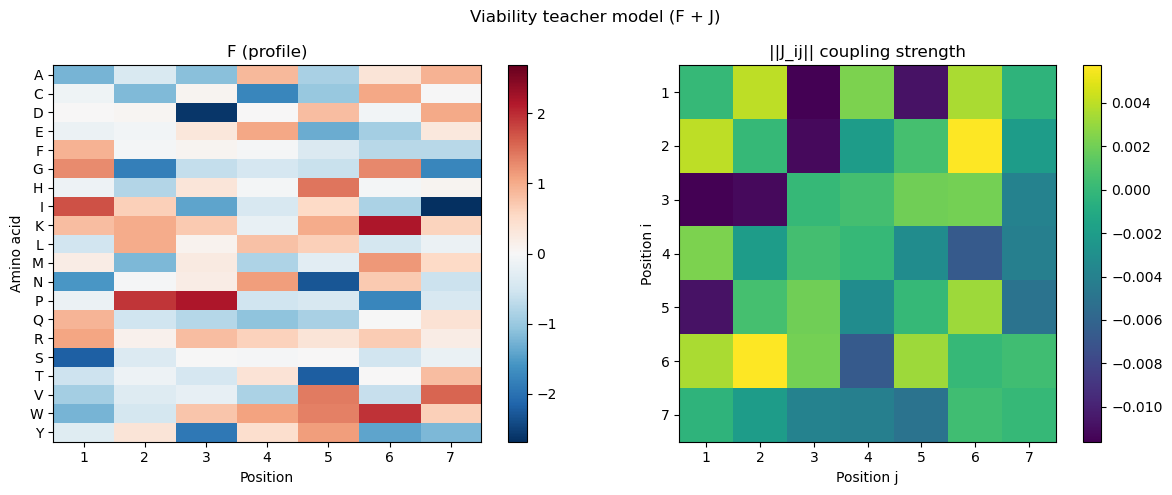

In [6]:
_ = plot_teacher_weights(F_viab, J_viab, title="Viability teacher model (F + J)")
plt.show()

## 3. Build the `Protocol`

`Protocol` wraps the whole simulation: `sequence` (identity, `(d0, 7)`, constant) and
`lambda0..lambda4` / `lambda0p,2p,3p` (abundance pools, all `(d0,)`, evolve each round).

In [7]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Initial library, colored by viability/selectivity score (function 2):

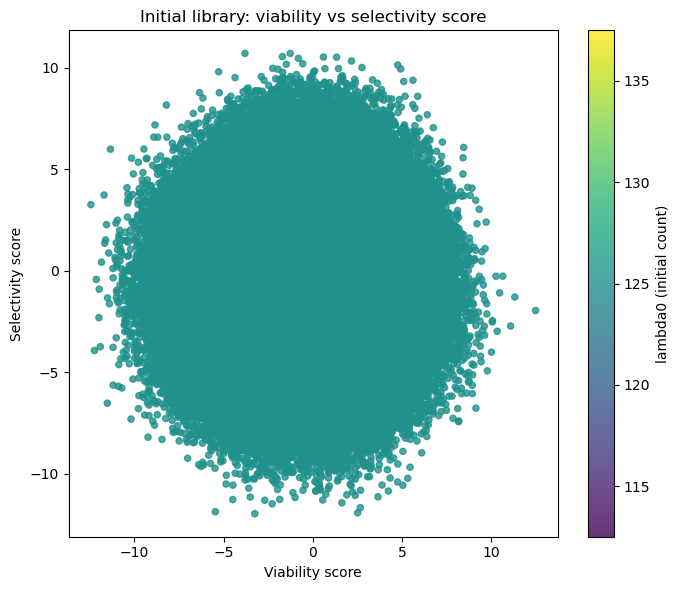

In [8]:
_ = plot_initial_library_scores(protocol)
plt.show()

## 4. Run one round of `loop_DE()`

In [9]:
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,129  non-zero=799997 / 800000
  lambda2    total=123,521,843,200  non-zero=9145 / 800000
  lambda3    total=43,054,538,752  non-zero=7981 / 800000
  lambda4    total=   100,000,712  non-zero=4732 / 800000
  lambda0p   total= 9,995,731,229  non-zero=799999 / 800000
  lambda2p   total= 9,684,674,931  non-zero=8118 / 800000
  lambda3p   total= 9,410,763,583  non-zero=6876 / 800000


Counts through viability + selectivity (function 3):

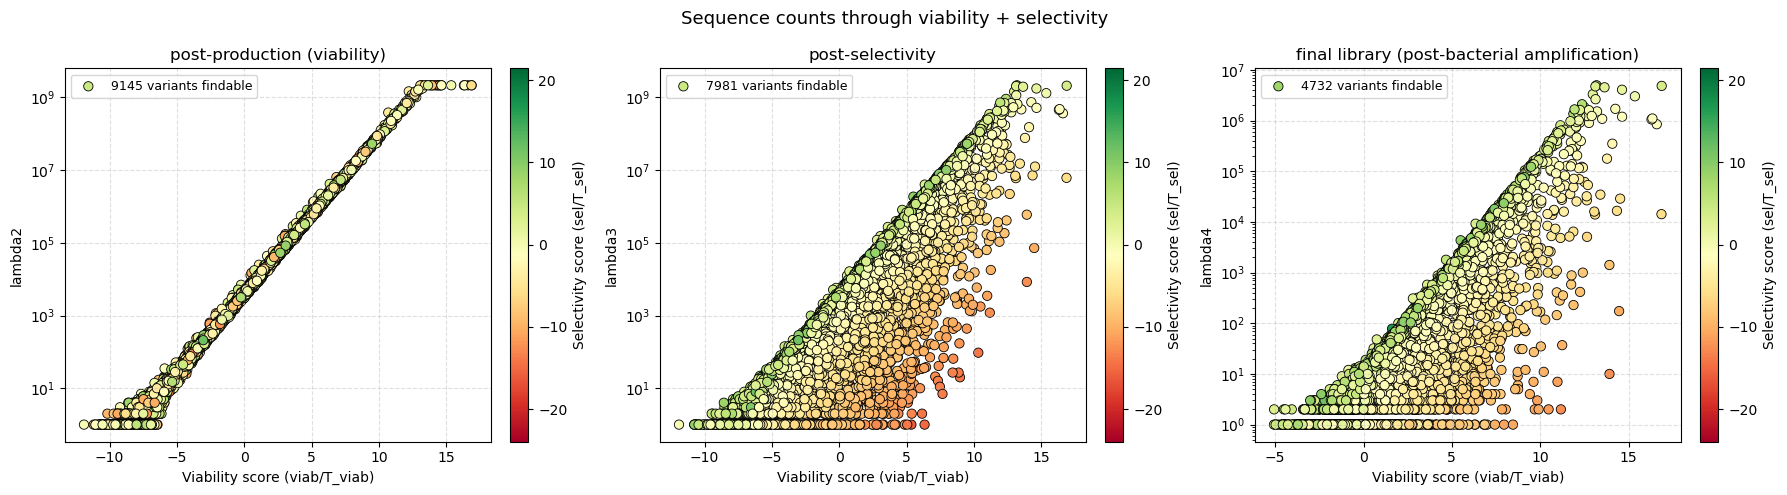

In [10]:
_ = plot_counts_after_selection(protocol)
plt.show()

All 8 lambdas of that same round on one plot (function 8):

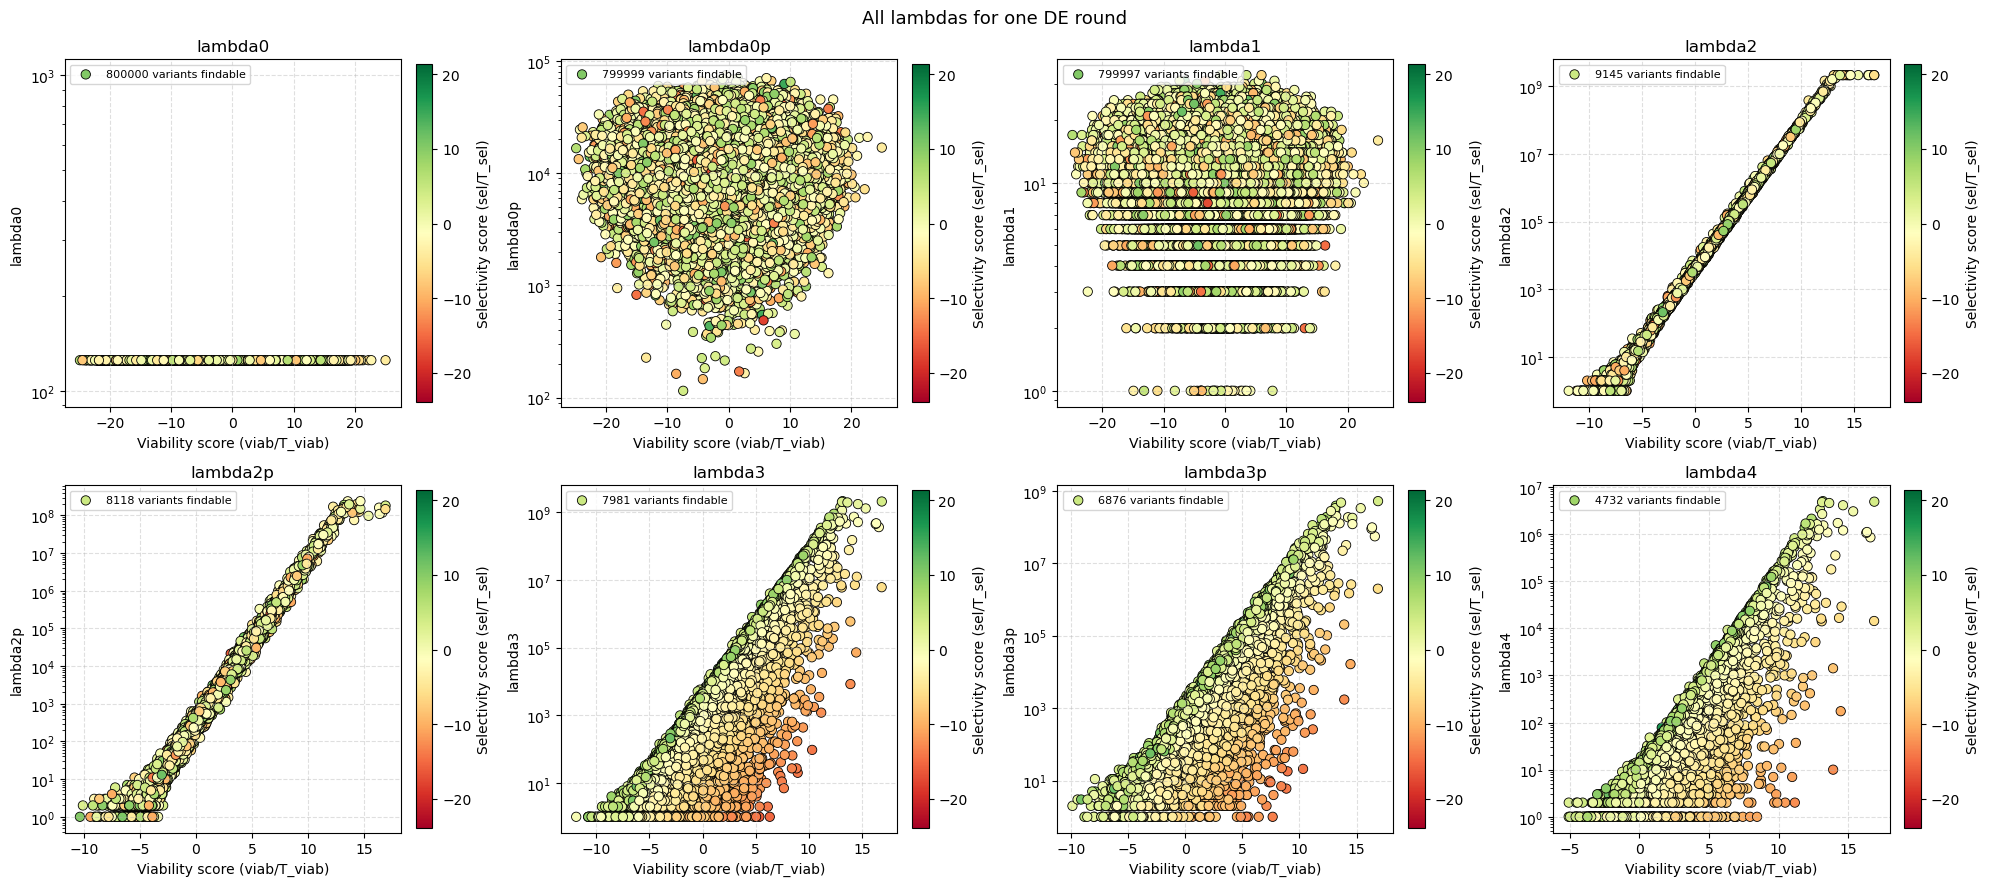

In [11]:
_ = plot_loop_lambdas(protocol, run_loop=False)  # reuse the round we just ran
plt.show()

## 5. Run several rounds with `N_loop_DE` and track library evolution

In [12]:
"""protocol_multi = ProtocolV2(
    N0=100_000_000, N1=10_000_000, sequences=sequences, 
    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, 
    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,
)

fig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)
plt.show()

print(f"N_loop_DE returned {len(rounds)} rounds")"""

'protocol_multi = ProtocolV2(\n    N0=100_000_000, N1=10_000_000, sequences=sequences, \n    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, \n    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,\n)\n\nfig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)\nplt.show()\n\nprint(f"N_loop_DE returned {len(rounds)} rounds")'

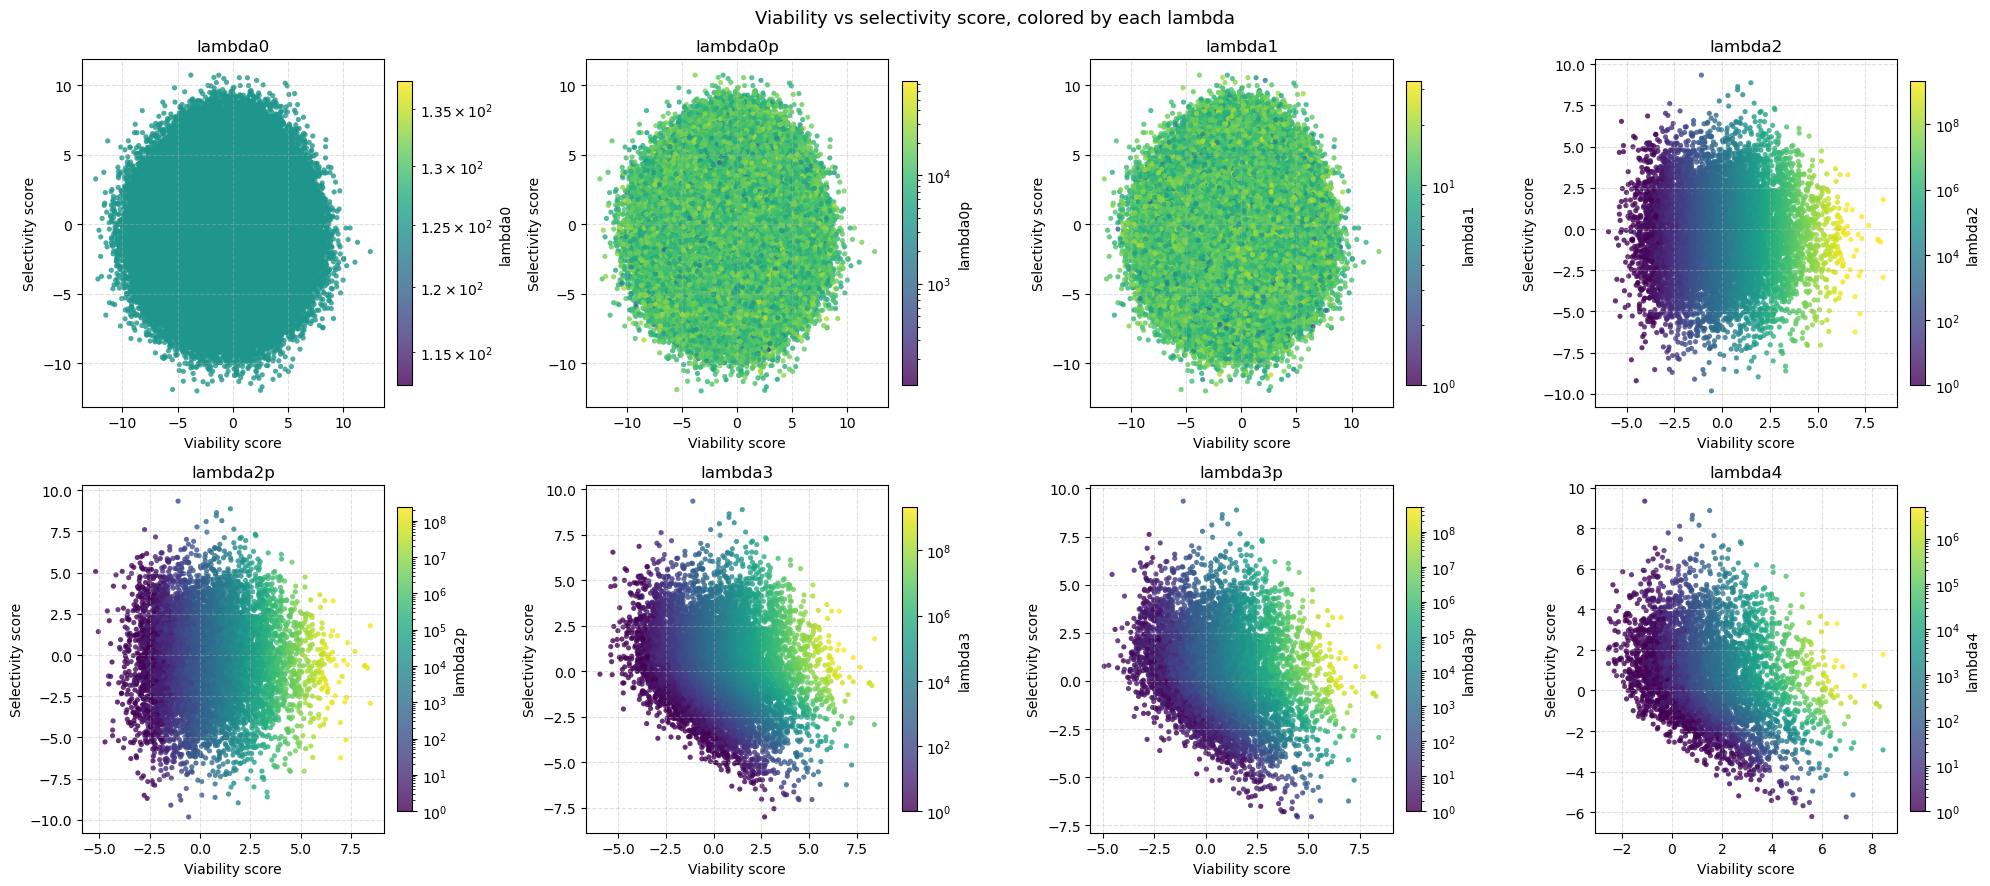

In [13]:
_ = plot_all_lambda_scores(protocol)
plt.show()

## Test 1 : Value of F, the factor of dilution

Whatever the value of D, a large part of sequences disappear in the NGS. Lets see how many sequences we have over some threshold.

In [14]:
threshold_values = [10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
lambdas          = [lambda0, lambda1, lambda2, lambda3, lambda4]
names            = ["lambda0", "lambda1", "lambda2", "lambda3", "lambda4"]

number_of_seq_threshold(lambdas=lambdas, thresholds=threshold_values, names=names)

,10.0,100.0,1000.0,10000.0,100000.0,1000000.0
lambda,,,,,,
lambda0,800000,800000,0,0,0,0
lambda1,638633,0,0,0,0,0
lambda2,8249,6983,5431,3688,2174,1069
lambda3,6742,5363,3899,2447,1389,647
lambda4,2983,1725,847,338,123,29


In [15]:
lambdaps         = [lambda0p, lambda2p, lambda3p]
namesp           = ["lambda0p", "lambda2p", "lambda3p"]
number_of_seq_threshold(lambdas=lambdaps, thresholds=threshold_values, names=namesp)

,10.0,100.0,1000.0,10000.0,100000.0,1000000.0
lambda,,,,,,
lambda0p,799999,799999,799737,479424,0,0
lambda2p,6835,5206,3504,1995,975,395
lambda3p,5882,4426,2933,1717,846,333


Relative proportions (`proportion_above_threshold` from `analysisV1.py`): how many sequences are abundant -- present above a given percentage of the pool total -- for the biological chain and the NGS reads separately.

In [16]:
pct_thresholds = [1, 0.1, 0.01, 0.001, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,0,0,0,0,800000,800000,800000,800000,800000,800000,800000
lambda1,0,0,0,0,638633,799997,799997,799997,799997,799997,799997
lambda2,32,145,388,1003,2035,3541,5274,6853,8128,8895,9145
lambda3,29,123,337,844,1721,2942,4465,5858,7117,7981,7981
lambda4,29,123,338,846,1722,2918,4169,4732,4732,4732,4732


In [17]:
pct_thresholds_p = [1e-4, 8*1e-5, 6*1e-5, 5.5*1e-5, 5*1e-5, 4.5*1e-5, 4*1e-5, 2*1e-5, 1e-5]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds_p, names=names)

,> 0.0001%,> 8e-05%,> 6e-05%,> 5.5e-05%,> 5e-05%,> 4.5e-05%,> 4e-05%,> 2e-05%,> 1e-05%
lambda,,,,,,,,,
lambda0,800000,800000,800000,800000,800000,800000,800000,800000,800000
lambda1,638633,744222,788131,788131,795799,795799,798772,799963,799997
lambda2,2035,2180,2346,2406,2462,2531,2591,3043,3541
lambda3,1721,1822,1968,2011,2054,2109,2177,2524,2942
lambda4,1722,1812,1970,2006,2050,2107,2171,2524,2918


In [18]:
proportion_above_threshold(lambdas=lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,0,0,479643,799737,799999,799999,799999,799999,799999
lambda2p,33,147,400,989,2015,3529,5231,6835,8118,8118,8118
lambda3p,32,119,343,860,1746,2963,4448,5882,6876,6876,6876


The factor of dilution can help signicantly to get rid of variants that are not the optimal variants. The effect on noise should be analyse for further conclusion.

In [19]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=1000, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


In [20]:
new_bio_row, new_ngs_row = protocol.loop_DE()
new_lambda0, new_lambda1, new_lambda2, new_lambda3, new_lambda4 = new_bio_row
new_lambda0p, new_lambda2p, new_lambda3p = new_ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", new_lambda0), ("lambda1", new_lambda1), ("lambda2", new_lambda2),
                    ("lambda3", new_lambda3), ("lambda4", new_lambda4),
                    ("lambda0p", new_lambda0p), ("lambda2p", new_lambda2p), ("lambda3p", new_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
new_lambdaps         = [new_lambda0p, new_lambda2p, new_lambda3p]

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,129  non-zero=799997 / 800000
  lambda2    total=123,521,843,200  non-zero=9145 / 800000
  lambda3    total=43,054,538,752  non-zero=7981 / 800000
  lambda4    total=   100,000,712  non-zero=4732 / 800000
  lambda0p   total=10,004,205,649  non-zero=94093 / 800000
  lambda2p   total= 9,684,900,069  non-zero=5810 / 800000
  lambda3p   total= 9,410,328,057  non-zero=4270 / 800000


In [21]:
proportion_above_threshold(lambdas=new_lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,0,38815,89670,93811,94092,94093,94093,94093,94093
lambda2p,33,147,400,990,2014,3545,5198,5810,5810,5810,5810
lambda3p,32,120,341,858,1735,2985,4188,4270,4270,4270,4270


Visualizing which variants disappear as dilution increases: every variant found in `lambda3p` is plotted (x = viability score, y = selectivity score), once per `dilution_factor`, layered from red (weak dilution, most variants present) up to blue (strong dilution, drawn last/on top). A point that stays visibly red was lost once dilution increased; a point that ends up blue survived even the strongest dilution tested -- this lets us check directly whether attrition is uniform across score-space or concentrated on low-score (inefficient, lower-abundance) variants. Note the inclusion is only approximate (~97-99.8% overlap between consecutive levels), since each `dilution_factor` redraws independent randomness rather than sub-sampling the previous draw.

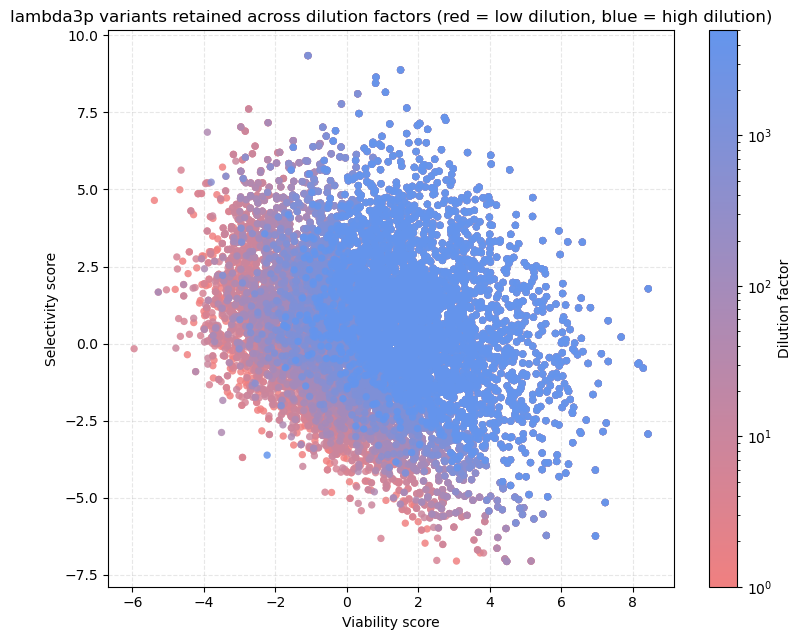

In [22]:
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

### Let's add some noise to see how dilution affects the results.

In [31]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=4, noise_sel=4,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


In [32]:
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,129  non-zero=799997 / 800000
  lambda2    total=463,616,442,368  non-zero=8661 / 800000
  lambda3    total=207,584,198,656  non-zero=7594 / 800000
  lambda4    total=    99,999,104  non-zero=3883 / 800000
  lambda0p   total= 9,995,731,229  non-zero=799999 / 800000
  lambda2p   total=10,070,846,717  non-zero=7140 / 800000
  lambda3p   total= 9,859,190,775  non-zero=6177 / 800000


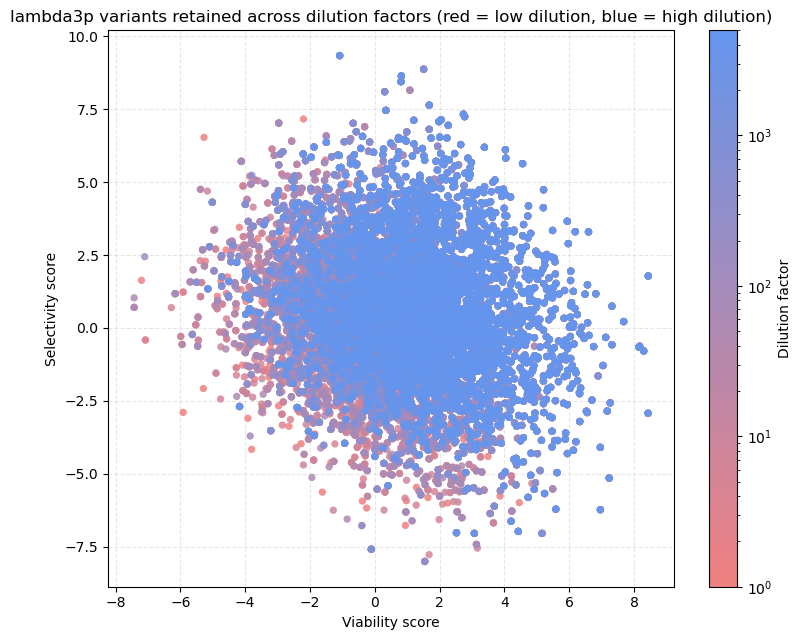

In [33]:
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

## Test 2 : 